In [ ]:
!pip install transformers datasets torch scikit-learn scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import pandas as pd
from skmultilearn.model_selection import IterativeStratification

def iterative_train_test_split_custom(X, y, test_size, random_state=None):
    """
    Splits X and y into two sets (train and test) using iterative stratification.
    The test set will have approximately the given test_size fraction of samples.
    """
    stratifier = IterativeStratification(
        n_splits=2,
        order=1,
        sample_distribution_per_fold=[1 - test_size, test_size]
    )
    # The generator returns (train_indices, test_indices)
    for train_idx, test_idx in stratifier.split(X, y):
        return X[test_idx], y[test_idx], X[train_idx], y[train_idx]

def stratified_split(df, x_col, stratify_cols, test_size, val_size=None, random_state=None):
    """
    Splits a DataFrame into stratified sets using iterative stratification.

    Parameters:
      df           : pandas DataFrame.
      x_col        : column name containing the features (e.g., "incident_summary").
      stratify_cols: list of column names to use for stratification.
      train_size   : fraction for training (used for information; priority is given to training and validation).
      test_size    : fraction for test set.
      val_size     : (optional) fraction for validation set. If None, a two-split (train/test) is performed.
      random_state : seed for reproducibility.

    Returns:
      If val_size is None:
         (X_train, y_train, X_test, y_test)
      Else:
         (X_train, y_train, X_val, y_val, X_test, y_test)

    Note: When using a validation set, it is assumed that train_size + test_size + val_size == 1.
    """
    # Shuffle the DataFrame if a random state is provided.
    if random_state is not None:
        df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Extract features and stratification labels.
    X = df[x_col].values
    y = df[stratify_cols].values

    if val_size is None:
        X_train, y_train, X_test, y_test = iterative_train_test_split_custom(X, y, test_size, random_state)
        return X_train, y_train, X_test, y_test
    else:
        # First, separate out the training data versus the temporary set (which will be split into val and test).
        temp_size = test_size + val_size
        X_train, y_train, X_temp, y_temp = iterative_train_test_split_custom(X, y, temp_size, random_state)

        # Now, split the temporary set into validation and test.
        # The ratio for the test portion of X_temp is: test_size / (test_size + val_size)
        ratio = test_size / temp_size
        X_val, y_val, X_test, y_test = iterative_train_test_split_custom(X_temp, y_temp, ratio, random_state)
        return X_train, y_train, X_val, y_val, X_test, y_test



In [ ]:

# X_train, y_train, X_test, y_test = stratified_split(
#     data,
#     x_col="incident_summary",
#     stratify_cols=[col for col in data.columns if col != "incident_summary"],
#     train_size=0.9,
#     test_size=0.1,
#     val_size=None,
#     random_state=42
# )

# print("=== Train/Test Split ===")
# print("Train incident_summary:", len(X_train))
# print("Test incident_summary:", len(X_test))


# X_train, y_train, X_val, y_val, X_test, y_test = stratified_split(
#     data,
#     x_col="incident_summary",
#     stratify_cols=[col for col in data.columns if col != "incident_summary"],
#     train_size=0.8,
#     test_size=0.1,
#     val_size=0.1,
#     random_state=42
# )
# print("\n=== Train/Validation/Test Split ===")
# print("Train incident_summary:",len(X_train))
# print("Validation incident_summary:",len(X_val) )
# print("Test incident_summary:", len(X_test))


In [ ]:
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# =======================
# Generalized Dataset Class
# =======================
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float),
        }

# =======================
# Function to Compute Metrics
# =======================
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

def compute_metrics(eval_pred, target_names):
    """
    Compute evaluation metrics for multi-label classification.
    Includes Hamming Loss, Subset Accuracy, and Classification Report for all labels.
    """
    logits, labels = eval_pred
    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy()  # Apply threshold
    labels = labels.astype(int)

    # Verify Labels
    print("Shape of labels:", labels.shape)  # Ensures correct dimensions
    print("First few rows of labels:\n", labels[:5])  # Shows the first few rows to check for issues
    print("Final target names:", target_names)

    # Hamming Loss
    hamming = hamming_loss(labels, predictions)

    # Subset Accuracy
    subset_acc = accuracy_score(labels, predictions)

    # Classification Report
    report = classification_report(
        labels, predictions,
        target_names=target_names,
        zero_division=0, output_dict=True
    )

    # Print complete report for reference
    print("\nFull Classification Report:")
    print(classification_report(labels, predictions, target_names=target_names, zero_division=0))


    # Summary Metrics for Trainer
    metrics = {
        "hamming_loss": hamming,
        "subset_accuracy": subset_acc,
    }
    metrics.update(report)
    return metrics

# =======================
# Reusable Training Function
# =======================
def train_transformer_model(model_name, data, max_len=512, test_size=0.1, val_size=0.1, batch_size=40, epochs=3):
    """
    Generalized function to train a transformer model for multi-label classification.
    Args:
        model_name: Name of the pre-trained model (e.g., "bert-base-uncased", "distilbert-base-uncased").
        data: Pandas DataFrame with columns "incident_summary" and multi-label columns.
        max_len: Maximum sequence length.
        batch_size: Batch size for training and evaluation.
        epochs: Number of training epochs.
    """
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=data.shape[1] - 1,  # Number of labels (all columns except "incident_summary")
        problem_type="multi_label_classification",
    )
    model.to("cuda" if torch.cuda.is_available() else "cpu")

    target_names = data.drop(columns=["incident_summary"]).columns.tolist()

    # Split data into train, val, and test
    X = data["incident_summary"]
    y = data.drop('incident_summary', axis=1).values

    # X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42) #stratify=y)
    # X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)




    # X_train, y_train, X_test, y_test = stratified_split(
    #     data,
    #     x_col="incident_summary",
    #     stratify_cols=[col for col in data.columns if col != "incident_summary"],
    #     train_size=0.9,
    #     test_size=0.1,
    #     val_size=None,
    #     random_state=42
    # )



    X_train, y_train, X_val, y_val, X_test, y_test = stratified_split(
        data,
        x_col="incident_summary",
        stratify_cols=[col for col in data.columns if col != "incident_summary"],
        test_size=test_size,
        val_size=val_size,
        random_state=42
    )


    # Create datasets
    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer, max_len)
    val_dataset = MultiLabelDataset(X_val.tolist(), y_val, tokenizer, max_len)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer, max_len)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model='eval_hamming_loss',
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
    )

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)
    )

    # Train and Evaluate
    trainer.train()

    # Final Evaluation on Test Set
    test_results = trainer.evaluate(test_dataset)
    print("Test Set Results:", test_results)

    return trainer, test_results


In [ ]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

In [ ]:
def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv"):
    """
    1. Iterates over the defined fractions & model list
    2. Samples df_full according to fraction
    3. Trains & evaluates using train_multiclass_model_3way_split
    4. Saves the collected results in a DataFrame
    5. Exports to CSV

    Args:
        df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
        output_csv (str): File path to save the experiment results.
    Returns:
        results_df (pd.DataFrame): Contains experiment results for analysis.
    """
    results_list = []

    for frac in fractions:
        # Sample a fraction of the data
        subset_size = int(len(df_full) * frac)
        df_subset = df_full.sample(n=subset_size, random_state=42)

        # Friendly fraction label if you want
        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

        for model_name in models_list:
            # Model label
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")

            # Train & evaluate
            # write the model funtion here
            trainer, test_results = train_transformer_model(model_name, df_subset, max_len=512, test_size=0.1, val_size=0.1, batch_size=16, epochs=2)


            # Build a result dict
            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }

            # Flatten the nested dictionary
            for key, value in test_results.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        # Create new key names like "armed_assault_precision"
                        run_result[f"{key}_{subkey}"] = subvalue
                else:
                    run_result[key] = value

            # Append to results_list
            results_list.append(run_result)

    # Convert to DataFrame
    results_df = pd.DataFrame(results_list)
    # Save to CSV
    results_df.to_csv(output_csv, index=False)
    print(f"\nResults saved to {output_csv}")

    # also save to JSON
    # results_df.to_json("experiment_results.json", orient="records")

    return results_df




# **Read From Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/colab/satp-data/target_type.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Read from GitHub**

In [ ]:
import pandas as pd

# Corrected URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/main/model-data-size-experiments/target_type/target_type.csv'

try:
    data = pd.read_csv(url)
    print(data.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

In [ ]:


selected_columns = ['former_maoist', 'high_caste_landowner', 'police_informer', 'businessman', 'aspiring_politician', 'other_elite', 'other_civilian', 'incident_summary']
data = data[selected_columns]

# Now 'data' contains only the selected columns.
print(data.head())


   former_maoist  high_caste_landowner  police_informer  businessman  \
0              0                     0                0            0   
1              0                     0                0            0   
2              0                     0                0            0   
3              0                     0                0            0   
4              0                     0                0            0   

   aspiring_politician  other_elite  other_civilian  \
0                    0            0               0   
1                    0            0               0   
2                    0            0               0   
3                    0            0               0   
4                    0            0               0   

                                    incident_summary  
0  An alleged arms supplier to the Communist Part...  
1  A Kamareddy dalam (squad) member belonging to ...  
2  Senior CPI-Maoist 'Polit Bureau' and 'central ...  
3  A TDP leader 

In [ ]:
# import pandas as pd

# def print_label_distribution(y, split_name, stratify_cols):
#     """
#     Prints the count of samples for each label in a given split.

#     Parameters:
#       y            : NumPy array with stratification labels (each column corresponds to a label)
#       split_name   : Name of the split (e.g., "Train", "Test", "Validation")
#       stratify_cols: List of label column names corresponding to the columns in y
#     """
#     df_labels = pd.DataFrame(y, columns=stratify_cols)
#     print(f"Label distribution in {split_name} set:")
#     for col in stratify_cols:
#         print(f"  {col} distribution:")
#         print(df_labels[col].value_counts())
#     print("\n")

# # Example usage after splitting:

# # Assuming 'stratify_cols' is defined as:
# stratify_cols = [col for col in data.columns if col != "incident_summary"]

# # For a two-split (Train/Test) scenario:
# print_label_distribution(y_train, "Train", stratify_cols)
# print_label_distribution(y_test, "Test", stratify_cols)

# # For a three-split (Train/Validation/Test) scenario:
# print_label_distribution(y_train, "Train", stratify_cols)
# print_label_distribution(y_val, "Validation", stratify_cols)
# print_label_distribution(y_test, "Test", stratify_cols)


Label distribution in Train set:
  civilians distribution:
civilians
0    6664
1    1270
Name: count, dtype: int64
  maoist distribution:
maoist
0    4352
1    3582
Name: count, dtype: int64
  government_officials distribution:
government_officials
0    7508
1     426
Name: count, dtype: int64
  security distribution:
security
0    7110
1     824
Name: count, dtype: int64
  private_property distribution:
private_property
0    7425
1     509
Name: count, dtype: int64
  mining_company distribution:
mining_company
0    7880
1      54
Name: count, dtype: int64
  ngos distribution:
ngos
0    7928
1       6
Name: count, dtype: int64
  government_infrastructure distribution:
government_infrastructure
0    7164
1     770
Name: count, dtype: int64
  non_maoist_armed_group distribution:
non_maoist_armed_group
0    7886
1      48
Name: count, dtype: int64
  no_target distribution:
no_target
0    6880
1    1054
Name: count, dtype: int64


Label distribution in Test set:
  civilians distribution:
c

## Run the Models

In [ ]:

# Example usage:
final_results_df = run_all_experiments_and_save(data, output_csv="experiment_results.csv")

# Now you can inspect final_results_df in Python:
print(final_results_df.head())

# If you want to do more analysis, you can pivot, group, or plot the data.



=== DATA FRACTION: 0.03125 (310 rows) ===
Training model: BERT


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

...

Shape of labels: (992, 7)
First few rows of labels:
 [[0 0 1 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]]
Final target names: ['former_maoist', 'high_caste_landowner', 'police_informer', 'businessman', 'aspiring_politician', 'other_elite', 'other_civilian']

Full Classification Report:
                      precision    recall  f1-score   support

       former_maoist       0.00      0.00      0.00         7
high_caste_landowner       0.00      0.00      0.00         1
     police_informer       0.95      0.95      0.95        37
         businessman       0.00      0.00      0.00         6
 aspiring_politician       0.00      0.00      0.00         2
         other_elite       0.00      0.00      0.00        19
      other_civilian       0.74      0.71      0.72        94

           micro avg       0.80      0.61      0.69       166
           macro avg       0.24      0.24      0.24       166
        weighted avg       0.63      0.61      0.62       

Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-base-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Hamming Loss,Subset Accuracy,Former Maoist,High Caste Landowner,Police Informer,Businessman,Aspiring Politician,Other Elite,Other Civilian,Micro avg,Macro avg,Weighted avg,Samples avg,Runtime,Samples Per Second,Steps Per Second
1,0.054400,0.060404,0.022155,0.865055,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 7.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 37.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 20.0}","{'precision': 0.7692307692307693, 'recall': 0.21052631578947367, 'f1-score': 0.3305785123966942, 'support': 95.0}","{'precision': 0.7692307692307693, 'recall': 0.11904761904761904, 'f1-score': 0.20618556701030927, 'support': 168.0}","{'precision': 0.1098901098901099, 'recall': 0.03007518796992481, 'f1-score': 0.047225501770956316, 'support': 168.0}","{'precision': 0.434981684981685, 'recall': 0.11904761904761904, 'f1-score': 0.18693427784336875, 'support': 168.0}","{'precision': 0.02014098690835851, 'recall': 0.019637462235649546, 'f1-score': 0.0198053037932192, 'support': 168.0}",8.052000,123.323000,7.824000
2,0.052400,0.051803,0.016832,0.908359,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 7.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.7777777777777778, 'recall': 0.9459459459459459, 'f1-score': 0.8536585365853658, 'support': 37.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 20.0}","{'precision': 0.6048387096774194, 'recall': 0.7894736842105263, 'f1-score': 0.684931506849315, 'support': 95.0}","{'precision': 0.650887573964497, 'recall': 0.6547619047619048, 'f1-score': 0.6528189910979229, 'support': 168.0}","{'precision': 0.19751664106502817, 'recall': 0.24791709002235315, 'f1-score': 0.21979857763352584, 'support': 168.0}","{'precision': 0.513318185697218, 'recall': 0.6547619047619048, 'f1-score': 0.5753205893115683, 'support': 168.0}","{'precision': 0.1107754279959718, 'recall': 0.10473313192346426, 'f1-score': 0.1067472306143001, 'support': 168.0}",8.068800,123.067000,7.808000


Shape of labels: (993, 7)
First few rows of labels:
 [[0 0 1 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0]]
Final target names: ['former_maoist', 'high_caste_landowner', 'police_informer', 'businessman', 'aspiring_politician', 'other_elite', 'other_civilian']

Full Classification Report:
                      precision    recall  f1-score   support

       former_maoist       0.00      0.00      0.00         7
high_caste_landowner       0.00      0.00      0.00         1
     police_informer       0.00      0.00      0.00        37
         businessman       0.00      0.00      0.00         5
 aspiring_politician       0.00      0.00      0.00         3
         other_elite       0.00      0.00      0.00        20
      other_civilian       0.77      0.21      0.33        95

           micro avg       0.77      0.12      0.21       168
           macro avg       0.11      0.03      0.05       168
        weighted avg       0.43      0.12      0.19       

Shape of labels: (992, 7)
First few rows of labels:
 [[0 0 1 0 0 0 0]
 [0 0 0 0 0 1 1]
 [0 0 1 0 0 0 0]
 [0 0 0 0 0 0 1]
 [0 0 0 0 0 0 1]]
Final target names: ['former_maoist', 'high_caste_landowner', 'police_informer', 'businessman', 'aspiring_politician', 'other_elite', 'other_civilian']

Full Classification Report:
                      precision    recall  f1-score   support

       former_maoist       0.00      0.00      0.00         7
high_caste_landowner       0.00      0.00      0.00         1
     police_informer       0.00      0.00      0.00        37
         businessman       0.00      0.00      0.00         6
 aspiring_politician       0.00      0.00      0.00         2
         other_elite       0.00      0.00      0.00        19
      other_civilian       0.85      0.18      0.30        94

           micro avg       0.85      0.10      0.18       166
           macro avg       0.12      0.03      0.04       166
        weighted avg       0.48      0.10      0.17       

## Commit Results to GitHub

In [ ]:
# commit csv to github using python

from github import Github
import pandas as pd
import os

# Replace with your GitHub personal access token
g = Github("your_github_access_token")

# Replace with your repository name and owner
repo = g.get_user("your_github_username").get_repo("your_repository_name")

# Specify the path to the CSV file in your Colab environment
csv_file_path = "experiment_results.csv"

# Check if the file exists
if not os.path.exists(csv_file_path):
    print(f"Error: CSV file '{csv_file_path}' not found.")
else:
    # Create a file object and commit
    try:
        with open(csv_file_path, 'rb') as file_obj:
            contents = repo.create_file(
                path="experiment_results.csv",  # Specify the path in your repository
                message="Committing CSV file from Colab",
                content=file_obj.read(),
                branch="main"  # Replace with your branch name
            )
        print("CSV file successfully committed to GitHub!")
    except Exception as e:
        print(f"Error committing CSV file to GitHub: {e}")


## Save to Disc

In [ ]:
import os


def save_to_drive(df, filename, folder_name="civ_targettype"):
    base_path = "/content/drive/MyDrive/colab/satp-results/"
    drive_path = os.path.join(base_path, folder_name)

    # Create the folder if it doesn't exist
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)

    filepath = os.path.join(drive_path, filename)
    df.to_csv(filepath, index=False)
    print(f"✅ DataFrame saved to: {filepath}")

save_to_drive(final_results_df, "civ_targettype_results.csv")


✅ DataFrame saved to: /content/drive/MyDrive/colab/satp-results/civ_targettype/civ_targettype_results.csv


## Analyze Results

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/civ_targettype/civ_targettype_results.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### F1 Micro

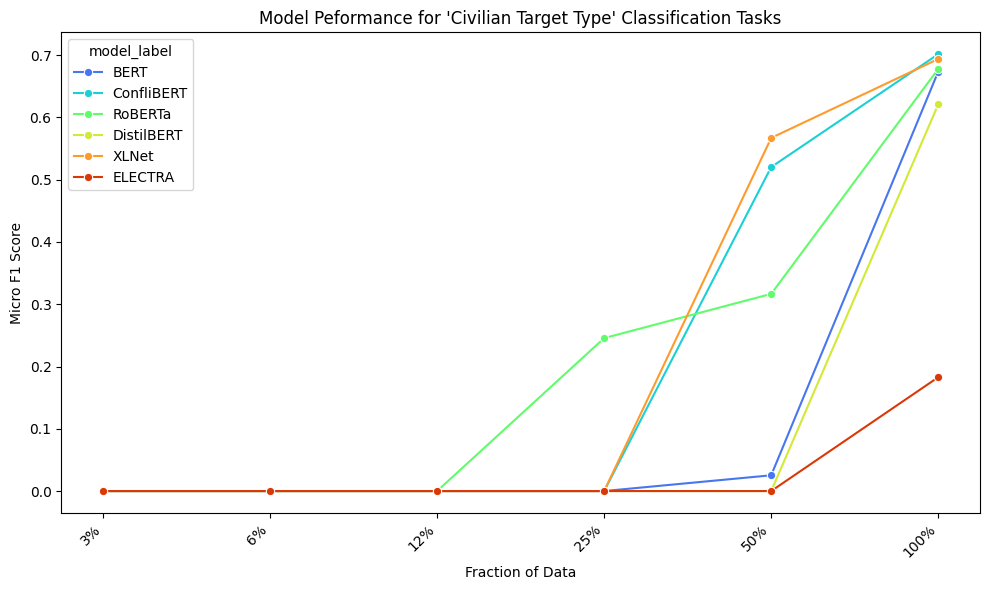

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="fraction_label",
    y="eval_micro avg_f1-score",
    hue="model_label",
    marker="o",
    palette="turbo"
    )

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Micro F1 Score")
plt.title("Model Peformance for 'Civilian Target Type' Classification Tasks")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Heatmap of individual labels

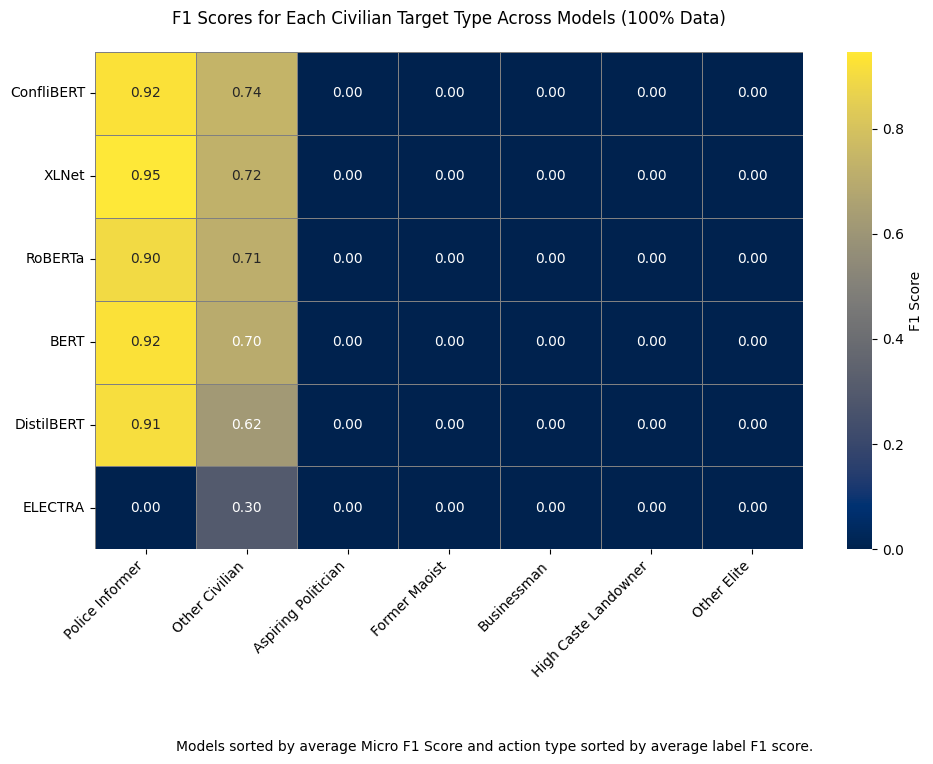

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset for models trained on 100% of the data
df_100 = df[df["fraction_label"] == "100%"]

# Extract F1-score columns related to specific labels (excluding averages)
label_f1_columns = [col for col in df_100.columns if col.startswith("eval_") and "_f1-score" in col and "avg" not in col]

# Select only the relevant columns along with the model label
df_f1_100 = df_100[["model_label"] + label_f1_columns]

# Rename "ConfliBERT-scr-cased" to "ConfliBERT" for clarity
#df_f1_100["model_label"] = df_f1_100["model_label"].replace({"ConfliBERT-scr-cased": "ConfliBERT"})

# Convert data to long format for heatmap visualization
df_f1_melted_100 = df_f1_100.melt(id_vars=["model_label"], var_name="Label", value_name="F1 Score")

# Clean label names (remove "eval_" prefix and "_f1-score" suffix for readability)
df_f1_melted_100["Label"] = df_f1_melted_100["Label"].str.replace("eval_", "").str.replace("_f1-score", "").str.replace("_", " ").str.title()

# Pivot the table so that models are on the y-axis and event types on the x-axis
df_f1_pivot_100 = df_f1_melted_100.pivot(index="model_label", columns="Label", values="F1 Score")

# Remove "Incident Summary" if it exists
df_f1_pivot_100 = df_f1_pivot_100.drop(columns="Incident Summary", errors="ignore")

# Sort event types (columns) by their average F1 score across models (descending order)
event_order = df_f1_pivot_100.mean().sort_values(ascending=False).index
df_f1_pivot_100 = df_f1_pivot_100[event_order]

# Sort models (rows) by their Micro F1 score (descending order) while ensuring all models are included
df_model_avg_f1 = df_100.set_index("model_label")["eval_micro avg_f1-score"].sort_values(ascending=False)
model_order = df_model_avg_f1.index
df_f1_pivot_100 = df_f1_pivot_100.loc[model_order]

# Plot the heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_f1_pivot_100, annot=True, fmt=".2f", cmap="cividis", linewidths=0.5, linecolor="gray", cbar_kws={'label': 'F1 Score'})

# Customize the plot
ax.set_title("F1 Scores for Each Civilian Target Type Across Models (100% Data)", pad=20)

# Add a custom note
plt.figtext(0.5, -0.08,
            "Models sorted by average Micro F1 Score and action type sorted by average label F1 score.",
            ha="center", fontsize=10)

# Remove X and Y axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Move event type labels (x-axis) to the bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# Adjust ticks
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.yticks(rotation=0)

# Show the heatmap
plt.tight_layout()
plt.show()


### Model performance vs. speed

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_speed_vs_accuracy(df, x_col, y_col, hue_col, size_col, title):
    """
    Creates a scatter (bubble) plot with customizable x and y axes.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis (e.g., throughput, latency)
    - y_col: Column name for the y-axis (e.g., accuracy, latency)
    - hue_col: Column name for the hue (color grouping, e.g., model name)
    - size_col: Column name for the size (bubble size, e.g., data fraction)
    - title: Custom plot title
    """

    # Initialize figure
    plt.figure(figsize=(7, 5))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,   # Color by model
        size=size_col,  # Bubble size by fraction
        sizes=(20, 400),  # Min to max size of markers
        alpha=0.7,  # Partial transparency
        palette="turbo"
    )

    # Clean up axis labels: Remove "eval_" prefix if present
    x_label_cleaned = x_col.replace("eval_", "").replace("_", " ").title()
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Labeling
    scatter.set_title(title)
    scatter.set_xlabel(x_label_cleaned)  # Use cleaned x-axis label
    scatter.set_ylabel(y_label_cleaned)  # Use cleaned y-axis label

    # Retrieve the current legend handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Convert column values to string for correct matching
    model_names = df[hue_col].astype(str).unique()
    fraction_values = sorted(df[size_col].astype(str).unique())

    # Filter legend items dynamically
    hue_handles = [h for h, l in zip(handles, labels) if l in model_names]
    hue_labels = [l for l in labels if l in model_names]

    size_handles = [h for h, l in zip(handles, labels) if l in fraction_values]
    size_labels = [l for l in labels if l in fraction_values]

    # Create the updated legends
    hue_legend = plt.legend(hue_handles, hue_labels, title="Model Name", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.gca().add_artist(hue_legend)  # Ensure the first legend stays

    size_legend = plt.legend(size_handles, size_labels, title="Fraction Raw", loc="lower left", bbox_to_anchor=(1.05, 0))

    # Show the plot
    plt.tight_layout()
    plt.show()


### Micro F1 vs. samples per second

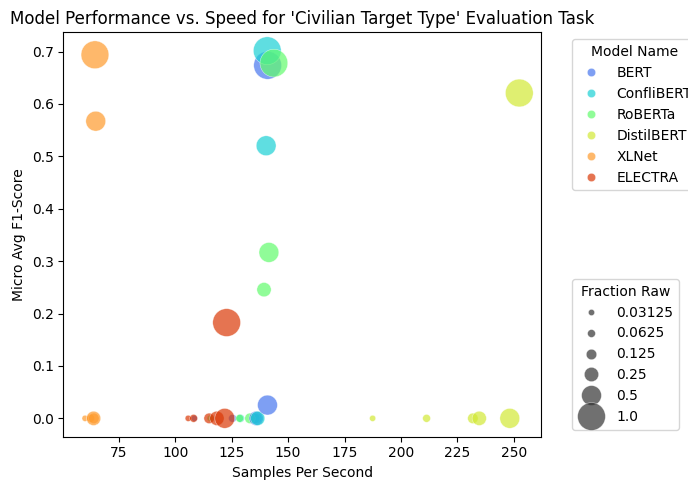

In [ ]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_samples_per_second",
    y_col="eval_micro avg_f1-score",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Civilian Target Type' Evaluation Task"
)